In [ ]:
image_1='/content/Edge Detection 1.jpg'
image_2='/content/Edge Detection 2.jpg'

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

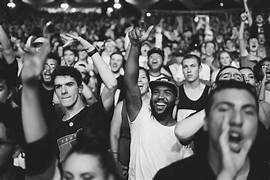

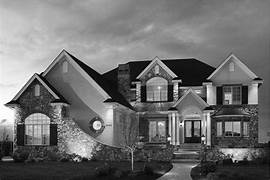

In [ ]:
from google.colab.patches import cv2_imshow
image_grey_1 = cv2.imread(image_1, cv2.IMREAD_GRAYSCALE)
image_grey_2 = cv2.imread(image_2, cv2.IMREAD_GRAYSCALE)
cv2_imshow(image_grey_1)
cv2_imshow(image_grey_2)

In [ ]:
from skimage import filters

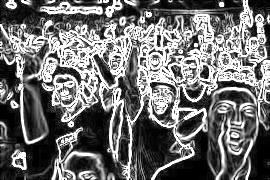

In [ ]:
sobel_x = cv2.Sobel(image_grey_1, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image_grey_1, cv2.CV_64F, 0, 1, ksize=3)
edges_sobel = cv2.magnitude(sobel_x, sobel_y)
cv2_imshow(edges_sobel)

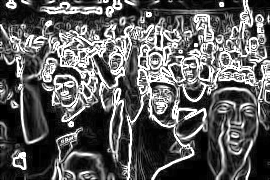

In [ ]:
prewitt_x = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
prewitt_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
image_grey_1_float32 = image_grey_1.astype(np.float32)
edges_prewitt_x = cv2.filter2D(image_grey_1_float32, -1, prewitt_x)
edges_prewitt_y = cv2.filter2D(image_grey_1_float32, -1, prewitt_y)
edges_prewitt = cv2.magnitude(edges_prewitt_x, edges_prewitt_y)
cv2_imshow(edges_prewitt)

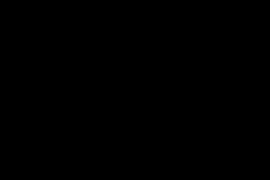

In [ ]:
edges_roberts = filters.roberts(image_grey_1)
cv2_imshow(edges_roberts)

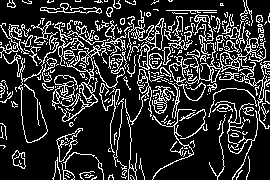

In [ ]:
edges_canny = cv2.Canny(image_grey_1, 100, 200)
cv2_imshow(edges_canny)

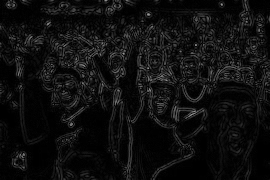

In [ ]:
blurred_image = cv2.GaussianBlur(image_grey_1, (3, 3), 0)
edges_log = cv2.Laplacian(blurred_image, cv2.CV_64F)
edges_log = np.abs(edges_log)
cv2_imshow(edges_log)

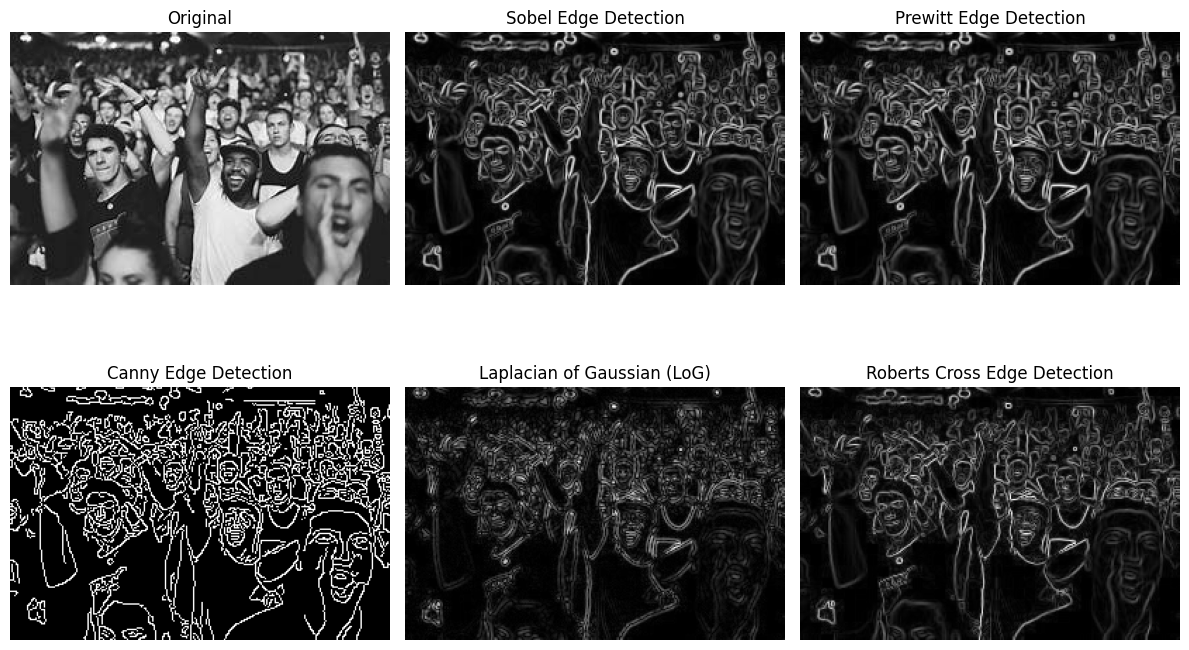

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

axes[0].imshow(image_grey_1, cmap='gray')
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(edges_sobel, cmap='gray')
axes[1].set_title("Sobel Edge Detection")
axes[1].axis("off")

axes[2].imshow(edges_prewitt, cmap='gray')
axes[2].set_title("Prewitt Edge Detection")
axes[2].axis("off")

axes[3].imshow(edges_canny, cmap='gray')
axes[3].set_title("Canny Edge Detection")
axes[3].axis("off")

axes[4].imshow(edges_log, cmap='gray')
axes[4].set_title("Laplacian of Gaussian (LoG)")
axes[4].axis("off")

axes[5].imshow(edges_roberts, cmap='gray')
axes[5].set_title("Roberts Cross Edge Detection")
axes[5].axis("off")

plt.tight_layout()
plt.show()